# PID Reaction Score Across Multiple Participants

This notebook generates a figure showing PID reaction score trajectories over time for different participants on the same graph. This supports the H2 hypothesis that the PID controller produced continuous, proportional responses across the sample.

**Note:** This notebook requires the raw adaptive session CSVs (`01_adaptive.csv`-`11_adaptive.csv`) and the CSV containing the SAM scores, file links and condition order (`participant_info.csv`) which are not included in the supporting material submission, consistent with the data access terms  agreed with participants (see Reflective Essay, Section 6). This notebook's cells retain their originally executed output below, so results remain visible and verifiable by inspection without requiring the underlying raw data.

In [1]:
import csv
import matplotlib.pyplot as plt
import statistics

## 1. Linking files to participants

In [2]:
def load_participants(filename="participant_info.csv"):
    """
    Loads participant info (file links, SAM scores, condition order) from participant_info.csv. 
    This file is not included in the supporting material submission, 
    consistent with the data access terms agreed with participants (see Reflective Essay, Section 6).
    """
    participants = []
    with open(filename, "r") as f:
        reader = csv.DictReader(f) # Allows to refer to columns by name
        for row in reader:
            participants.append({ # Building a dictionary for each row
                "id": row["participant_id"],
                "adaptive_file": row["adaptive_file"],
                "static_file": row["static_file"],
                "sam_baseline": int(row["sam_baseline"]),
                "sam_adaptive": int(row["sam_adaptive"]),
                "sam_static": int(row["sam_static"]),
                "order": row["order"],
            })
    return participants


participants = load_participants()

## 2. Choosing participants for the graph

In [3]:
def read_pid_scores(filename):
    scores = []
    with open(filename, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            score = float(row["reaction_score"])
            scores.append(score)
    return scores


print("SYSTEM STABILITY RESULTS")
print()

stability_results = []

for p in participants:
    
    filename = p["adaptive_file"]
    scores = read_pid_scores(filename)

    std_dev = statistics.stdev(scores) # Using stdev to measure overall spread

    step_changes = [] # Calculating beat-to-beat jumps
    
    for i in range(1, len(scores)): # Looking at every score, starting at the second one (index 1)
        previous_score = scores[i - 1]
        current_score = scores[i]
    
        difference = abs(current_score - previous_score) # abs() ensures the gap is always a positive number
        step_changes.append(difference)
        
    mean_step_change = sum(step_changes) / len(step_changes) # Findig the final average of all jumps

    std_dev_rounded = round(std_dev, 1)
    step_rounded = round(mean_step_change, 2)
    
    print(f"Participant: {p['id']} | Std Dev: {std_dev_rounded} | Mean Step Change: {step_rounded}")

    stability_results.append({ # Saving the final math for later
        "id": p["id"],
        "std_dev": std_dev,
        "mean_step_change": mean_step_change,
    })

SYSTEM STABILITY RESULTS

Participant: P01 | Std Dev: 13.0 | Mean Step Change: 3.5
Participant: P02 | Std Dev: 23.2 | Mean Step Change: 6.4
Participant: P03 | Std Dev: 21.1 | Mean Step Change: 5.57
Participant: P04 | Std Dev: 41.2 | Mean Step Change: 9.49
Participant: P05 | Std Dev: 17.8 | Mean Step Change: 3.42
Participant: P06 | Std Dev: 24.9 | Mean Step Change: 5.52
Participant: P07 | Std Dev: 10.0 | Mean Step Change: 4.24
Participant: P08 | Std Dev: 18.0 | Mean Step Change: 4.22
Participant: P09 | Std Dev: 40.7 | Mean Step Change: 6.27
Participant: P10 | Std Dev: 16.2 | Mean Step Change: 3.07
Participant: P11 | Std Dev: 42.0 | Mean Step Change: 15.69


The participants with the 4 smoothest trajectories (lowest standard deviation) are selected.

In [4]:
participants_to_plot = ["P07", "P01", "P10", "P05"] 

## 3. Reading the time and PID score data for the selected participants

In [5]:
def read_adaptive_csv(filename):
    """Reads time and PID reaction score per heartbeat."""
    time_seconds = []
    pid_scores = []

    with open(filename, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                time_seconds.append(float(row["time_seconds"]))
                pid_scores.append(float(row["reaction_score"]))
            except (ValueError, KeyError):
                pass

    return time_seconds, pid_scores


plot_data = {}

for p in participants:
    if p["id"] in participants_to_plot:
        print(f"Loading {p['id']} from {p['adaptive_file']}...")
        t, pid = read_adaptive_csv(p["adaptive_file"])
        plot_data[p["id"]] = {"time": t, "pid": pid}

Loading P01 from 01_adaptive.csv...
Loading P05 from 05_adaptive.csv...
Loading P07 from 07_adaptive.csv...
Loading P10 from 10_adaptive.csv...


## 4. Plotting the PID reaction score for each selected participant

Saved as: multi_participant_trajectories.png


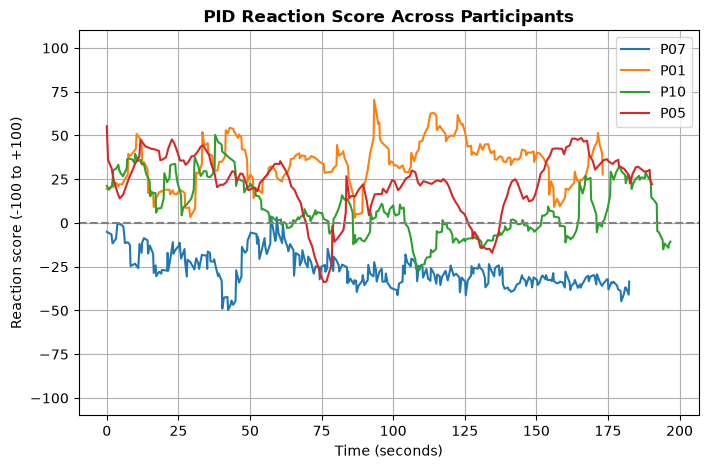

In [6]:
plt.figure(figsize=(8, 5))
plt.title("PID Reaction Score Across Participants", fontweight="bold") # Title

for person in participants_to_plot: # Drawing each participant's line
    
    time_data = plot_data[person]["time"] # Getting this specific individual's time and score data
    score_data = plot_data[person]["pid"]

    plt.plot(time_data, score_data, label=person) # Drawing the line

plt.axhline(0, color="gray", linestyle="--") # Drawing dashed horizontal line across the middle (0) to see when scores fall into negative

plt.xlabel("Time (seconds)")
plt.ylabel("Reaction score (-100 to +100)")
plt.ylim(-110, 110)

plt.legend(loc="upper right") # Adding a legend in the top right corner that tells which color is which person

plt.grid(True) # Turning background into grid lines to track trajectories more easily

# Saving and showing the final image
plt.savefig("multi_participant_trajectories.png", bbox_inches="tight") # Saving image, "tight" to trim unnecessary blank space
print("Saved as: multi_participant_trajectories.png")

plt.show()